# 🎬 Can we Predict Box Office Success? (IMDb Top 1000) 

**Can IMDb data alone predict flops from blockbusters?** 

Using **IMDb Top 1000 Movies** → classify gross into **3 tiers** (Flop/Mid/Blockbuster) from ratings, votes, runtime, genres, certificates.

**Why classification?**  Gross is heavily skewed → **3-class problem** 

---

## 🧹 1. Data Cleaning
- **Gross**: Removed `$` and turned into numeric (**Rows with missing gross values (16.9%) were removed.**)
- **Runtime**: Removed `"min"` and converted into integer 
- **Dropped**: Title, overview, posters and actors (To keep it structured and without NlP for now)

## 🔧 2. Feature Engineering

  ### 2.1 Target Engineering 🎯
For movies released before the 2000s, crossing $10M was very difficult to earn even though it would have been a blockbuster. While nowadays, a movie can easily earn $10M even though it's considered flop. Instead, i came up with solution that for each year i am going to use quantiles as shown in the table.
| Class | Conditions | Count |
|-------|-------------|-------|
| **Flop** | For each year, if under 50th quantile  | 441 |
| **Mid** | For each year, if between 50th quantile and 85th quantile | 233 |
| **Blockbuster** | For each year, if above 85th quantile | 156 |


### 2.2 Feature Pipeline 
- **Numeric**: Impute → Scale → Box-Cox (votes skew 2.08)  
- **Certificate**: Most-frequent → OneHot  
- **Genre**: Custom binarizer (25+ flags)  
- **Skewed**: Dedicated Box-Cox pipeline

## 🔗 3. Pipeline Architecture
- Built separate pipelines for different feature types 
- Combined them using a ColumnTransformer, then wrapped everything into a single pipeline.

## 🏆 4. Models Trained (Base models without using Optuna Tuning)

### 4.1 Softmax Regression 
- **Test Accuracy**: **70-71%** 
- **Macro F1**: **0.65**
- **Class F1**: Flop(**0.79**) > Blockbuster(**0.61**) > Mid(**0.60**)

### 4.2 Decision Tree
- **Test Accuracy**: **66-67 %**
- **Macro F1**: **0.58**
- **Class F1**: Flop(**0.76**) > Blockbuster(**0.53**) = Mid(**0.53**)

### 4.3 XGBoost
- **Test Accuracy**: **65 %**
- **Macro F1**: **0.5813**
- **Class F1**: Flop(**0.78**) > Mid(**0.51**) > Blockbuster(**0.46**) 




---
## Important Note:
- Class imbalance is inherent to the problem — blockbusters are rare by definition. Macro F1 is used to avoid inflating the model accuracy on the majority class.
- In this dataset, not all movies are blockbuster - critically acclaimed films like 12 Angry Men was a flop on Box-office.
- Cast/director star power was excluded intentionally to keep features pre-release and structured.

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split, cross_val_score
from io import StringIO

## 1. Data Cleaning

- Dropped text fields: Poster_Link, Series_Title, Overview, Director, Star1–Star4.
- Cleaned `Runtime` by removing `"min"` and converting to integer minutes.
- Dropped rows where **Gross** was null so the target is fully observed.
- Converted core columns into classes for Feature Engineering.
- Split the dataset into **train (70%)** and **test (30%)** for fair evaluation.


In [2]:
imdb=pd.read_csv('./top_1000_movies_data.csv')

In [3]:
imdb=imdb.drop(['Poster_Link','Series_Title','Overview','Director','Star1','Star2','Star3','Star4'],axis=1)

In [4]:
imdb["Gross"]=imdb["Gross"].str.replace(",","",regex=True)
imdb["Gross"]=pd.to_numeric(imdb["Gross"],errors='coerce')
imdb.sample(5)

,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross
536,1976,U,138 min,"Biography, Drama, History",7.9,84.0,103031,70600000.0
431,1964,A,99 min,"Action, Drama, Western",8.0,65.0,198219,14500000.0
804,1997,U,119 min,"Drama, Mystery, Sci-Fi",7.7,NaN,64082,368234.0
8,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,74.0,2067042,292576195.0
214,2012,U,151 min,"Comedy, Drama, Romance",8.1,NaN,75721,2804874.0


In [5]:
imdb["Runtime"]=imdb["Runtime"].str.replace("min","",regex=True)
imdb.head(5)

,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross
0,1994,A,142,Drama,9.3,80.0,2343110,28341469.0
1,1972,A,175,"Crime, Drama",9.2,100.0,1620367,134966411.0
2,2008,UA,152,"Action, Crime, Drama",9.0,84.0,2303232,534858444.0
3,1974,A,202,"Crime, Drama",9.0,90.0,1129952,57300000.0
4,1957,U,96,"Crime, Drama",9.0,96.0,689845,4360000.0


In [6]:
imdb.dtypes

Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Meta_score       float64
No_of_Votes        int64
Gross            float64
dtype: object

In [7]:
imdb["Released_Year"]= pd.to_numeric(imdb['Released_Year'], errors='coerce')
imdb["Runtime"]=pd.to_numeric(imdb["Runtime"],errors='coerce')
imdb.dtypes

Released_Year    float64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Meta_score       float64
No_of_Votes        int64
Gross            float64
dtype: object

In [8]:
imdb.isnull().mean()*100

Released_Year     0.1
Certificate      10.1
Runtime           0.0
Genre             0.0
IMDB_Rating       0.0
Meta_score       15.7
No_of_Votes       0.0
Gross            16.9
dtype: float64

In [9]:
imdb=imdb.dropna(subset=['Gross'])
imdb.isnull().mean()*100

Released_Year    0.120337
Certificate      5.535499
Runtime          0.000000
Genre            0.000000
IMDB_Rating      0.000000
Meta_score       9.747292
No_of_Votes      0.000000
Gross            0.000000
dtype: float64

## 2. Feature Engineering

### 2.1 Target Engineering

Gross binned into **3 classes** for easier modeling:

| Class | Conditions | Count |
|-------|-------------|-------|
| **Flop** | For each year, if under 50th quantile  | 441 |
| **Mid** | For each year, if between 50th quantile and 85th quantile | 233 |
| **Blockbuster** | For each year, if above 85th quantile | 156 |

Why? Raw gross is heavily right-skewed and as classification gives interpretable targets. To make it fair, for each year the particualr quantiles decide which movies belongs in which category.


In [10]:
def label_by_year(group):
    q_50 = group['Gross'].quantile(0.50)
    q_85 = group['Gross'].quantile(0.85)
    
    group['target'] = np.where(
        group['Gross'] <= q_50, 'Flop',
        np.where(group['Gross'] <= q_85, 'Mid', 'Blockbuster')
    )
    return group

imdb = imdb.groupby('Released_Year', group_keys=False).apply(label_by_year)
imdb['target'].value_counts()


C:\Users\Hp\AppData\Local\Temp\ipykernel_7932\281732996.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  imdb = imdb.groupby('Released_Year', group_keys=False).apply(label_by_year)


target
Flop           441
Mid            233
Blockbuster    156
Name: count, dtype: int64

In [11]:
imdb.columns

Index(['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating',
       'Meta_score', 'No_of_Votes', 'Gross', 'target'],
      dtype='object')

In [12]:
imdb=imdb.drop(['Gross'],axis=1)

In [13]:
imdb['target'].value_counts()

target
Flop           441
Mid            233
Blockbuster    156
Name: count, dtype: int64

In [14]:
X=imdb.drop(["target"],axis=1)
y =imdb['target']

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

X_train=X_train.reset_index(drop=True)
y_train=y_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)
y_test=y_test.reset_index(drop=True)

In [16]:
y_test.value_counts()

target
Flop           132
Mid             70
Blockbuster     47
Name: count, dtype: int64

In [17]:
y_train.value_counts()

target
Flop           309
Mid            163
Blockbuster    109
Name: count, dtype: int64

### Feature groups for the pipeline

To keep the pipeline readable, features are grouped by behaviour:

- **Numeric**: `Released_Year`, `Runtime`, `Meta_score`, `IMDB_Rating`.
- **Categorical**: `Certificate`.
- **Multi-label text**: `Genre`.
- **Positively skewed signals**: `No_of_Votes`.


In [18]:
num_cols=["Released_Year","Runtime","Meta_score",'IMDB_Rating']
cat_cols=["Certificate"]
multi_col=["Genre"]
pos_skew=['No_of_Votes']

In [19]:
imdb[num_cols].skew().sort_values(ascending=False)

IMDB_Rating      1.079833
Runtime          0.960548
Meta_score      -0.580173
Released_Year   -1.183354
dtype: float64

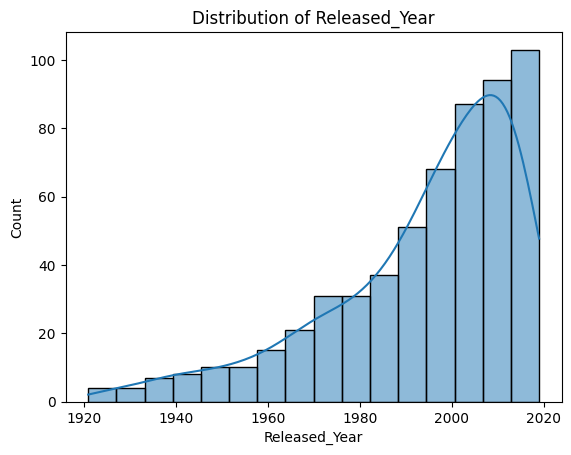

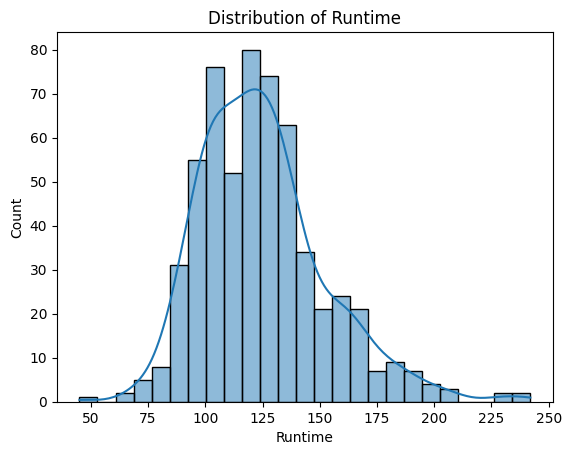

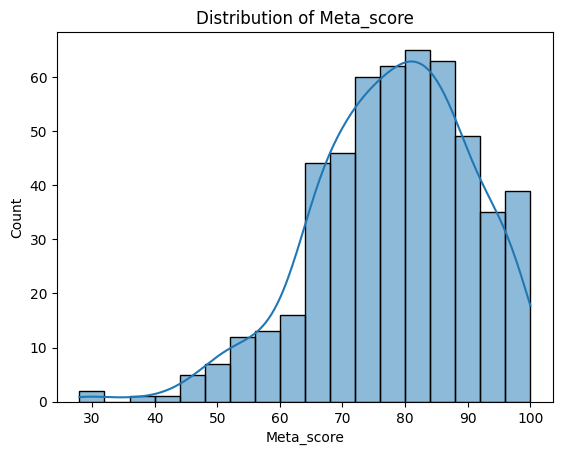

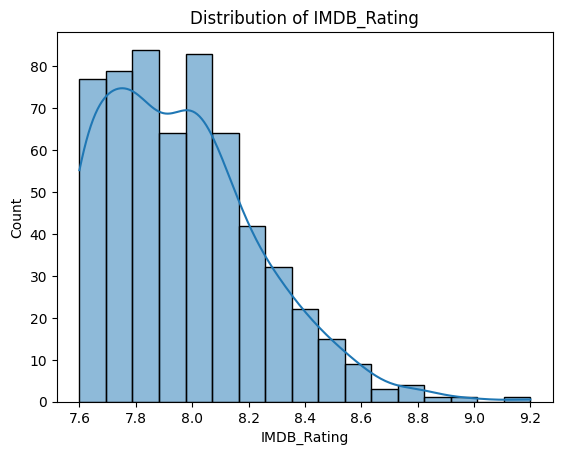

In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt 

for col in num_cols:
    plt.figure()
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

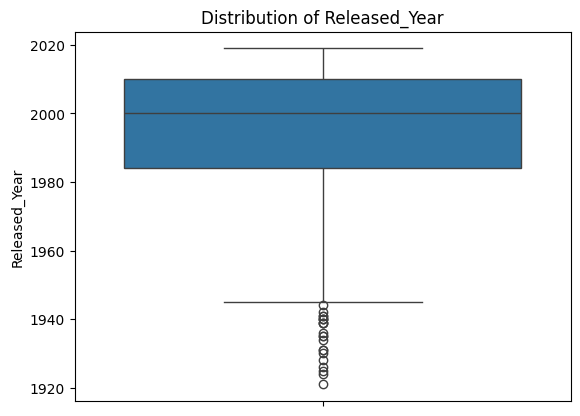

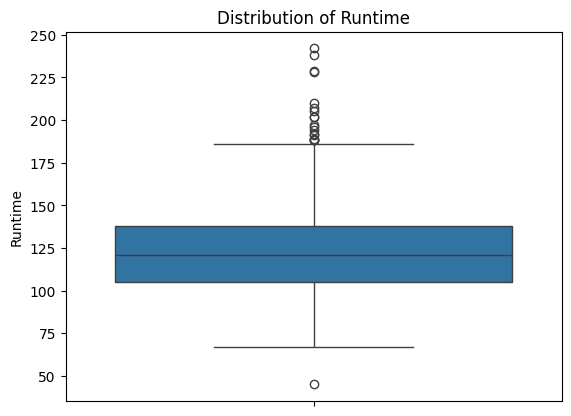

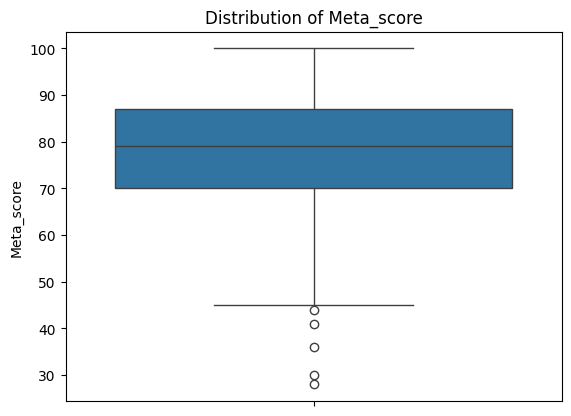

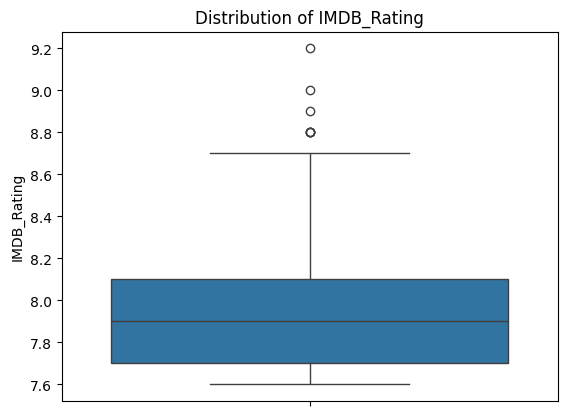

In [21]:
for col in num_cols:
    plt.figure()
    sns.boxplot(X_train[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [22]:
X_train.columns

Index(['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating',
       'Meta_score', 'No_of_Votes'],
      dtype='object')

### 2.2 Feature Pipeline

Features grouped by transformation needs:

**Numeric** (`Released_Year`, `Runtime`, `Meta_score`,`IMDB_Rating`):
- `SimpleImputer(strategy='mean')` → Meta_score (15.7% missing)
- `StandardScaler` → Normalize wildly different scales

**Categorical** (`Certificate`):
- `SimpleImputer(strategy='most_frequent')` → 5.5% missing  
- `OneHotEncoder(handle_unknown='ignore')` → A, UA, U, etc.

**Multi-label** (`Genre`):
- **Custom `GenreBinarizer`** → "Action, Drama" → 25+ binary columns

**Skewed signals** (`No_of_Votes`):
- `SimpleImputer` + `PowerTransformer(method='box-cox')` + `StandardScaler`


In [23]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler, MultiLabelBinarizer, PowerTransformer
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [24]:
trf1=Pipeline([
    ('impute',SimpleImputer(strategy='mean')),
    ('scale',StandardScaler())
])

In [25]:
trf2=Pipeline([
    ('imp_certi',SimpleImputer(strategy='most_frequent')),
    ('certi',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [26]:
class GenreBinarizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.mlb = MultiLabelBinarizer()
        self.mlb.fit(X['Genre'].str.split(', '))
        return self

    def transform(self, X):
        return self.mlb.transform(X['Genre'].str.split(', '))

    def get_feature_names_out(self, input_features=None):
        return self.mlb.classes_


In [27]:
trf4=Pipeline([
    ('impute',SimpleImputer(strategy="mean")),
    ('skew',PowerTransformer(method='box-cox')),
    ('scale',StandardScaler())
])

In [28]:
trf3=ColumnTransformer([
    ('num',trf1,num_cols),
    ('cat',trf2,cat_cols),
    ('genre',GenreBinarizer(),multi_col),
    ('trf4',trf4,pos_skew)
],
remainder='passthrough'
)

## 3. Pipeline Architecture

End‑to‑end **feature pipeline** so every model sees the same cleaned, scaled, and encoded inputs:

- Numeric block → impute missing values, scale, and de‑skew noisy signals like votes.
- Certificate block → impute + one‑hot encode censorship ratings.
- Genre block → explode multi‑label `Genre` into 25+ binary features (Action, Drama, etc.).
- Skewed‑signal block → dedicated Box–Cox + scaling for `No_of_Votes` and `IMDB_Rating`.

All of this is wrapped in a single `ColumnTransformer`, so train/test and future models stay perfectly consistent.


In [29]:
pipe=Pipeline([
    ('trf3',trf3)
])
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [30]:
X_train_transformed = trf3.fit_transform(X_train)

feature_names=trf3.get_feature_names_out()


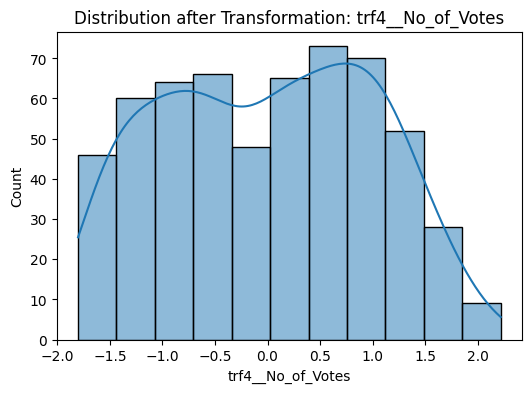

In [31]:
transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

for col in ['trf4__No_of_Votes']:
    plt.figure(figsize=(6, 4))
    sns.histplot(transformed_df[col], kde=True)
    plt.title(f'Distribution after Transformation: {col}')
    plt.show()

## 4. Models Trained

### 4.1 Softmax Regression 
- Trained on the full feature pipeline after trying multiple regularization and solver settings.
- **Precision Score** ≈ 66–67% on unseen movies.
- **Macro F1** around 65–66% 
- **Class-wise**: Strongest on Flop and Mid movies, weaker on Blockbuster.



In [74]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.linear_model import LogisticRegression
smr=LogisticRegression()
smr.fit(X_train_transformed,y_train)
X_test_transformed = trf3.transform(X_test)
y_pred_smr=smr.predict(X_test_transformed)

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_smr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smr))

Accuracy Score: 0.7068

Classification Report:
              precision    recall  f1-score   support

 Blockbuster       0.61      0.53      0.57        47
        Flop       0.79      0.83      0.81       132
         Mid       0.60      0.60      0.60        70

    accuracy                           0.71       249
   macro avg       0.67      0.65      0.66       249
weighted avg       0.70      0.71      0.70       249



In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test, y_pred_smr,average='macro'))

0.6665370566749146


In [77]:
print(recall_score(y_test,y_pred_smr,average='macro'))

0.6525574897915324


In [78]:
print(f1_score(y_test,y_pred_smr,average='macro'))

0.6585297418630752


### 4.2 Decision Tree

- Hyperparameter used : criterion as gini, max_depth as 3 giving the best result 
- **Precision score** ~60–61% 
- **F1 score (macro)** ~0.59  


In [68]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion="gini",max_depth=3, splitter="best",max_features=26)
dt.fit(X_train_transformed,y_train)
y_pred_dt=dt.predict(X_test_transformed)

In [69]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy Score: 0.6827

Classification Report:
              precision    recall  f1-score   support

 Blockbuster       0.85      0.23      0.37        47
        Flop       0.75      0.88      0.81       132
         Mid       0.53      0.61      0.57        70

    accuracy                           0.68       249
   macro avg       0.71      0.58      0.58       249
weighted avg       0.71      0.68      0.66       249



In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(f1_score(y_test, y_pred_dt,average='macro'))

0.5815218199485684


In [71]:
print(recall_score(y_test,y_pred_dt,average='macro'))

0.5757053820883608


In [72]:
print(f1_score(y_test,y_pred_dt,average='macro'))

0.5815218199485684


### Tree Visualization Key Takeaways
- Most important features are:
    - **Adventure(Genre)**: Acts as the primary split, the importance of genre in distinguishing box office performance levels.
    - **No.of Votes and Certificates(R,PG-13)**: are secondary decision factors, refining predictions based on audience engagement and target audience preferences.


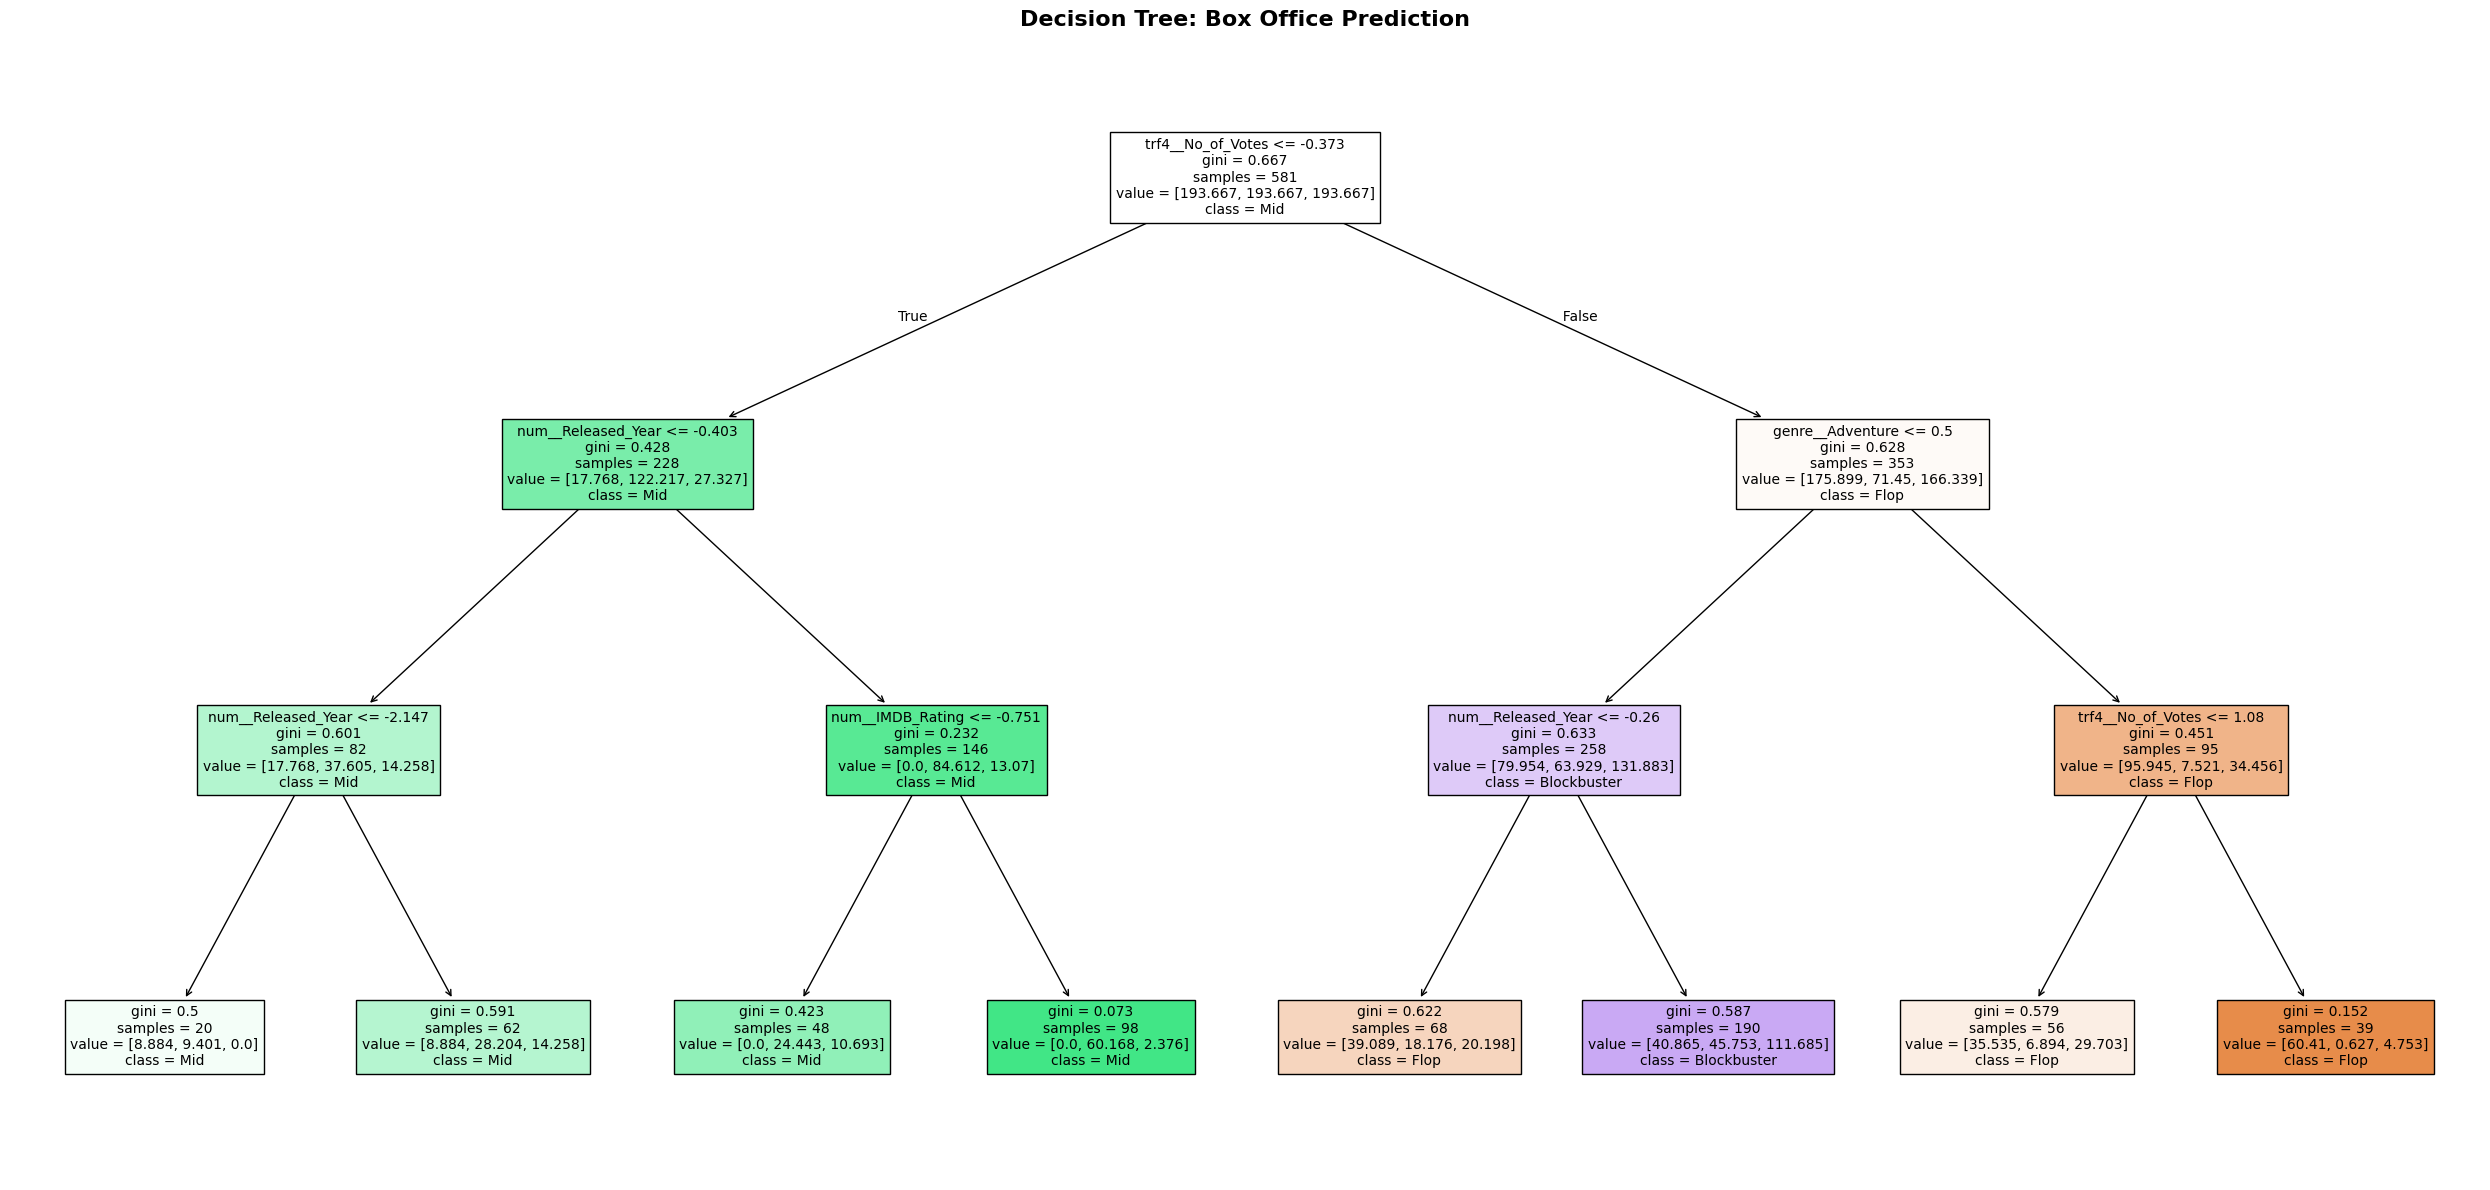

In [42]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25, 12))

plot_tree(dt, feature_names=trf3.get_feature_names_out(), class_names=['Flop', 'Mid', 'Blockbuster'], filled=True, impurity=True, max_depth=3,fontsize=10)

plt.title("Decision Tree: Box Office Prediction", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3. Xgboost
A baseline XGBoost classifier with default hyperparameters was evaluated to assess whether boosting could capture nonlinear patterns in IMDb metadata.

- **Test Accuracy**- 65%
- **Macro F1-Score**- 0.58

The baseline model performed comparably to the decision tree but did not outperform the softmaxx classifier, whcih suggests limited nonlinear signal in the feature space.

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

In [65]:
from xgboost import XGBClassifier

xgb=XGBClassifier()

xgb.fit(X_train_transformed, y_train_xgb)
y_pred_xgb=xgb.predict(X_test_transformed)

In [66]:
print(f1_score(y_test_xgb, y_pred_xgb,average='macro'))

0.5772087340341857


In [67]:
print(f"Accuracy Score: {accuracy_score(y_test_xgb, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

Accuracy Score: 0.6506

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.38      0.42        47
           1       0.78      0.81      0.80       132
           2       0.51      0.53      0.52        70

    accuracy                           0.65       249
   macro avg       0.58      0.57      0.58       249
weighted avg       0.64      0.65      0.65       249



### 5. Optuna Tuning

#### 5.1. Decision Tree

In [47]:
import optuna

In [48]:
def objf_dt(trial):
    criterion=trial.suggest_categorical('criterion',["gini","entropy"])
    splitter=trial.suggest_categorical('splitter',["best","random"])
    max_depth=trial.suggest_int('max_depth',3,7)
    max_features=trial.suggest_int('max_features',25,30)
    
    model_dt=DecisionTreeClassifier(
        criterion=criterion,
        splitter=splitter,
        max_depth=max_depth,
        max_features=max_features
    )
    
    score_dt=cross_val_score(model_dt,X_train_transformed,y_train,cv=5,scoring="f1_macro").mean()
    return score_dt
    

In [49]:
study_dt=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler())
study_dt.optimize(objf_dt,n_trials=150)
optuna.logging.set_verbosity(optuna.logging.WARNING)

[I 2026-03-29 16:16:44,490] A new study created in memory with name: no-name-83cacd71-d356-4d20-9952-092745b65533
[I 2026-03-29 16:16:44,556] Trial 0 finished with value: 0.5398993171376756 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 4, 'max_features': 25}. Best is trial 0 with value: 0.5398993171376756.
[I 2026-03-29 16:16:44,587] Trial 1 finished with value: 0.5048580428487252 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 3, 'max_features': 28}. Best is trial 0 with value: 0.5398993171376756.
[I 2026-03-29 16:16:44,643] Trial 2 finished with value: 0.5378200131843476 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 7, 'max_features': 29}. Best is trial 0 with value: 0.5398993171376756.
[I 2026-03-29 16:16:44,683] Trial 3 finished with value: 0.5290221371601616 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 4, 'max_features': 25}. Best is trial 0 with value: 0.5398993171376756.
[I 

In [50]:
print(study_dt.best_trial.value)
print(study_dt.best_trial.params)

0.574178234838276
{'criterion': 'entropy', 'splitter': 'best', 'max_depth': 4, 'max_features': 30}


In [51]:
dt_best=DecisionTreeClassifier(**study_dt.best_trial.params,random_state=42)

dt_best.fit(X_train_transformed, y_train)
y_pred_dt_best=dt_best.predict(X_test_transformed)

In [52]:
print(f1_score(y_test, y_pred_dt_best,average='macro'))

0.5971369104687


#### 5.2. Xgboost

In [53]:
def objf_xgb(trial):
    max_depth=trial.suggest_int('max_depth',3,20)
    learning_rate=trial.suggest_float('learning_rate',0.1,0.5)
    n_estimators=trial.suggest_int('n_estimators',50,200)
    subsample=trial.suggest_float('subsample',0.7,0.9)
    colsample_bytree=trial.suggest_float('colsample_bytree',0.7,0.9)
    
    model=XGBClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
    )
    
    score=cross_val_score(model,X_train_transformed,y_train_xgb,cv=3,scoring="f1_macro",).mean()
    return score

In [54]:
study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler())
study.optimize(objf_xgb,n_trials=150)

In [55]:
print(study.best_trial.value)
print(study.best_trial.params)

0.6127461769432664
{'max_depth': 16, 'learning_rate': 0.1270305093984903, 'n_estimators': 76, 'subsample': 0.7408129926908633, 'colsample_bytree': 0.875402865634212}


In [56]:
xgb_best=XGBClassifier(**study.best_trial.params,random_state=42)

xgb_best.fit(X_train_transformed, y_train_xgb)
y_pred_xgb_best=xgb_best.predict(X_test_transformed)

In [57]:
print(f1_score(y_test_xgb, y_pred_xgb_best,average='macro'))

0.6236905806435554


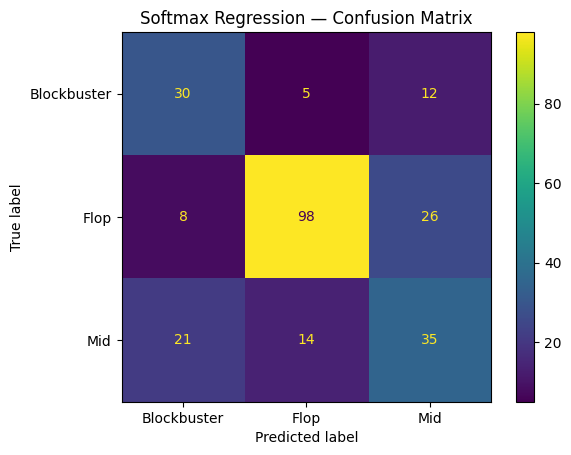

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smr, display_labels=['Blockbuster','Flop','Mid'])
plt.title("Softmax Regression — Confusion Matrix")
plt.show()

### Top 15 Important Features for deciding Blockbuster (Softmaxx Regression)

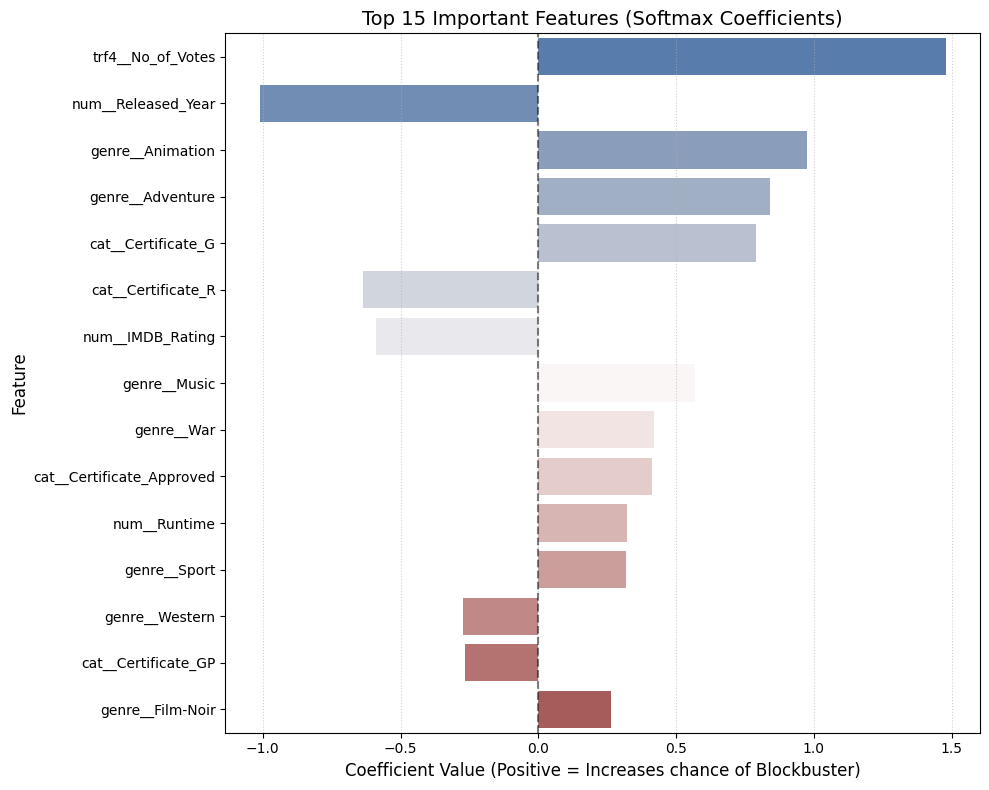

In [59]:
import seaborn as sns
feature_names = trf3.get_feature_names_out()

blockbuster_idx = np.where(smr.classes_ == 'Blockbuster')[0][0]
coefs = smr.coef_[blockbuster_idx]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
})

top_15 = importance_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_15, 
    x='Coefficient', 
    y='Feature', 
    palette='vlag', 
    hue='Feature',
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.title('Top 15 Important Features (Softmax Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value (Positive = Increases chance of Blockbuster)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 🎯 6. Summary

### 📊 Key Takeaways
- **IMDb metadata alone enables moderate predictive performance** on a 3-class box office classification task (Macro F1 ≈ 0.65), highlighting both the value and limits of pre-release signals.
- **Multinomial Logistic Regression (Softmax)** emerged as a strong baseline, which indicates that **linear relationships dominate** across ratings, votes, and genre-based features.
- **Tree-based models (XGBoost, Decision Tree) showed mixed results**: while default models underperformed, hyperparameter tuning closed the gap for XGBoost.
- **Blockbusters were the hardest class to predict**, because of the class imbalance.

### ⚙️ Model Selection & Hyperparameter Tuning
Optuna tuning was applied only to tree-based models to evaluate whether tuning hyperparameters could extract nonlinear signal from the dataset.

| Model | Setting | Macro F1 |
|------|--------|---------|
| Softmax Regression | Manual tuning | **0.658** |
| Decision Tree | Optuna | **0.581**|
| XGBoost | Optuna | **0.653** |

While XGBoost benefited from hyperparameter tuning and approached the performance of softmax regression, gains were marginal. Given comparable performance, simpler and more interpretable models were preferred.

### 🧠 Why XGBoost didn't dominate
- IMDb feature space combines pre- and post-release signals (ratings, votes) but lacks the nonlinear richness boosting methods typically exploit.
- Class imbalance and sparse blockbuster-specific indicators further constrained performance. (Used class_weight='balanced' but accuracy dropped)

### 🎬 Limitations
- **Budget, screen count, release timing, and marketing spend**—key drivers of revenue are unavailable.
- **Post-release dynamics** such as word-of-mouth and competitive releases are not captured.
- **Cast and director star power** was excluded to avoid noisy text-based modeling.

Overall, results suggest that while structured IMDb metadata captures general trends in movie performance, it is insufficient for reliably identifying high-end outliers such as blockbusters.
